# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...


remote: Enumerating objects: 10, done.
Receiving objects:  10% (1/10)
Receiving objects:  20% (2/10)


remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects:  50% (5/10), 8.23 MiB | 4.01 MiB/s
Receiving objects:  60% (6/10), 8.23 MiB | 4.01 MiB/s
Receiving objects:  70% (7/10), 8.23 MiB | 4.01 MiB/s
Receiving objects:  80% (8/10), 8.23 MiB | 4.01 MiB/s
Receiving objects:  90% (9/10), 8.23 MiB | 4.01 MiB/s
Receiving objects: 100% (10/10), 8.23 MiB | 4.01 MiB/s
Receiving objects: 100% (10/10), 11.01 MiB | 4.40 MiB/s, done.


Resolving deltas: 100% (2/2)
Resolving deltas: 100% (2/2), done.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])


Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
# Carregamento dos dados de validação via torchvision
import torchvision

test_dataset = torchvision.datasets.MNIST(dataset_dir, train=False, download=True,
    transform=torchvision.transforms.ToTensor())

x_val_full = test_dataset.data.float() / 255.
y_val_full = test_dataset.targets

n_samples_val = 200
x_val = x_val_full[:n_samples_val]
y_val = y_val_full[:n_samples_val]

print('Amostras de validação:', x_val.size(0))
print('Dimensões:', x_val.size())



  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  0%|          | 32.8k/9.91M [00:00<00:32, 308kB/s]


  1%|          | 65.5k/9.91M [00:00<00:32, 301kB/s]


  1%|▏         | 131k/9.91M [00:00<00:22, 433kB/s] 


  2%|▏         | 197k/9.91M [00:00<00:19, 496kB/s]

...


 81%|████████▏ | 1.34M/1.65M [00:01<00:00, 1.55MB/s]


100%|██████████| 1.65M/1.65M [00:01<00:00, 1.03MB/s]


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 8.09MB/s]

Amostras de validação: 200
Dimensões: torch.Size([200, 28, 28])


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

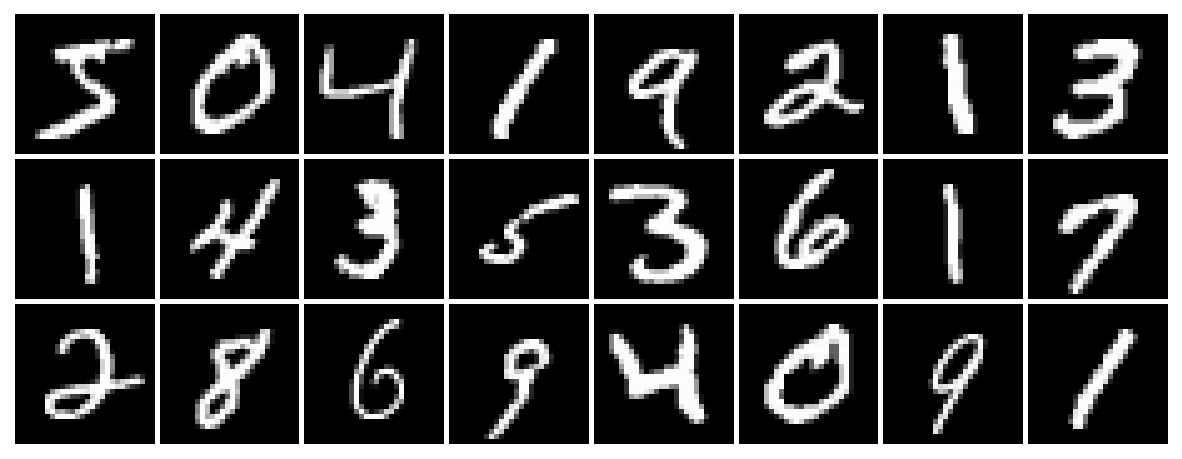

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


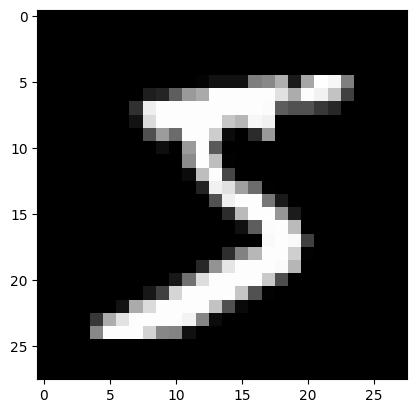

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.2423,  0.0866, -0.2941,  0.1099, -0.2816, -0.2209, -0.3361,  0.0866,
          0.0560, -0.0454],
        [-0.2876, -0.0050, -0.2704, -0.0384, -0.2424, -0.3125, -0.4877,  0.1965,
          0.0884,  0.0793],
        [-0.1114,  0.0383,  0.0944,  0.0389, -0.0077, -0.0862, -0.2120,  0.1868,
          0.0118, -0.0536],
        [-0.2075,  0.0552, -0.3663, -0.1292, -0.0080, -0.0468, -0.2220,  0.1393,
          0.0418, -0.2245],
        [-0.2794,  0.3476, -0.2748, -0.1323,  0.0024, -0.1800, -0.2326,  0.1566,
         -0.1079, -0.0774]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2636, Train Acc: 0.9420, Val Loss: 0.3909, Val Acc: 0.9050
Epoch [2/100], Train Loss: 0.2623, Train Acc: 0.9420, Val Loss: 0.3899, Val Acc: 0.9050
Epoch [3/100], Train Loss: 0.2609, Train Acc: 0.9420, Val Loss: 0.3890, Val Acc: 0.9050
Epoch [4/100], Train Loss: 0.2597, Train Acc: 0.9420, Val Loss: 0.3881, Val Acc: 0.9050
Epoch [5/100], Train Loss: 0.2584, Train Acc: 0.9420, Val Loss: 0.3872, Val Acc: 0.9050
Epoch [6/100], Train Loss: 0.2571, Train Acc: 0.9420, Val Loss: 0.3863, Val Acc: 0.9050
Epoch [7/100], Train Loss: 0.2559, Train Acc: 0.9440, Val Loss: 0.3854, Val Acc: 0.9050
Epoch [8/100], Train Loss: 0.2547, Train Acc: 0.9440, Val Loss: 0.3846, Val Acc: 0.9050
Epoch [9/100], Train Loss: 0.2534, Train Acc: 0.9440, Val Loss: 0.3837, Val Acc: 0.9050
Epoch [10/100], Train Loss: 0.2522, Train Acc: 0.9440, Val Loss: 0.3829, Val Acc: 0.9100
Epoch [11/100], Train Loss: 0.2510, Train Acc: 0.9440, Val Loss: 0.3821, Val Acc: 0.9100
Epoch [12/100], Train Loss: 0.

In [14]:
print('Final loss:', loss.item())

Final loss: 0.2649046778678894


### Visualizando gráfico de perda durante o treinamento

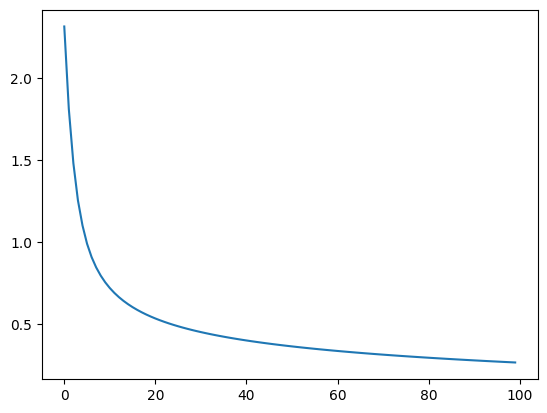

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

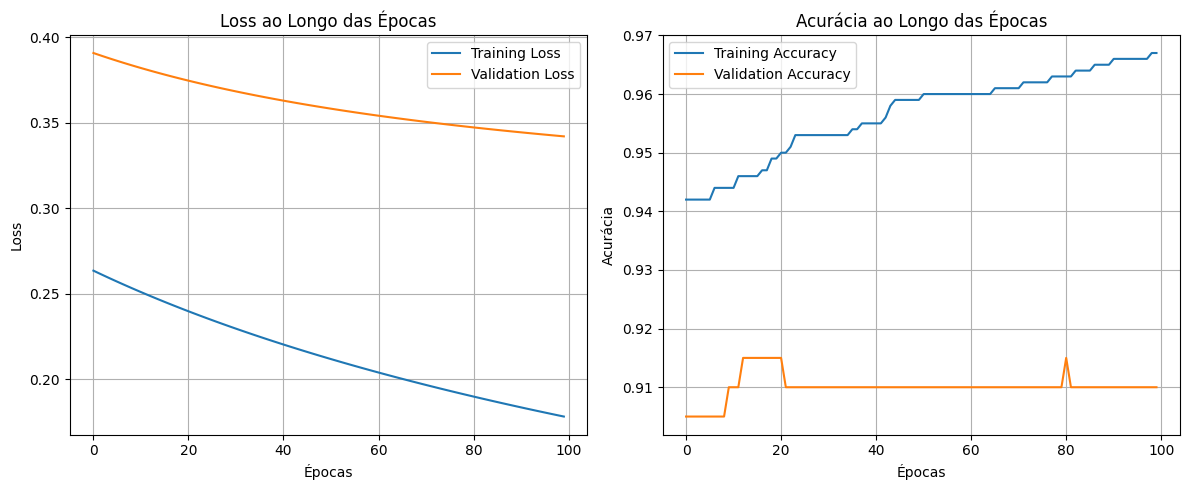

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.968


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,0,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,1,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,2,2,0,0,0,0,0,86,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


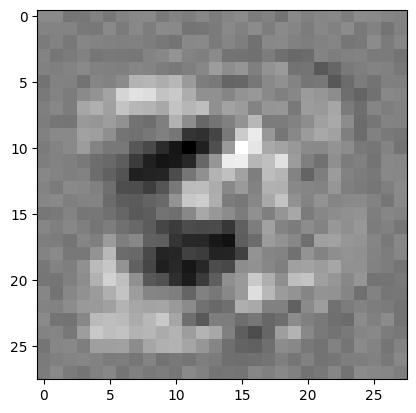

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

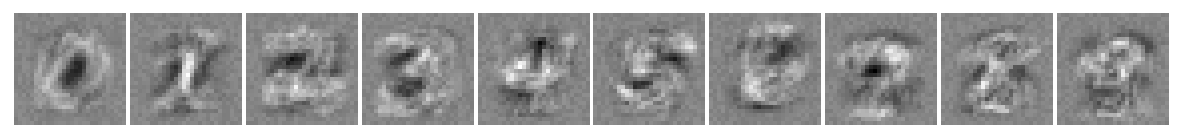

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados


---
## Exercícios — Soluções

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school


### Exercício 1 — Impressão de Época, Loss e Acurácia



  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  0%|          | 32.8k/9.91M [00:00<00:32, 306kB/s]


  1%|          | 65.5k/9.91M [00:00<00:31, 308kB/s]


  1%|          | 98.3k/9.91M [00:00<00:31, 311kB/s]


  1%|▏         | 131k/9.91M [00:00<00:31, 312kB/s] 

...


 95%|█████████▌| 1.57M/1.65M [00:01<00:00, 2.28MB/s]


100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 16.5MB/s]

Época [10/30] | Loss: 0.6481 | Acurácia: 86.00%
Época [20/30] | Loss: 0.4429 | Acurácia: 90.60%
Época [30/30] | Loss: 0.3522 | Acurácia: 92.40%


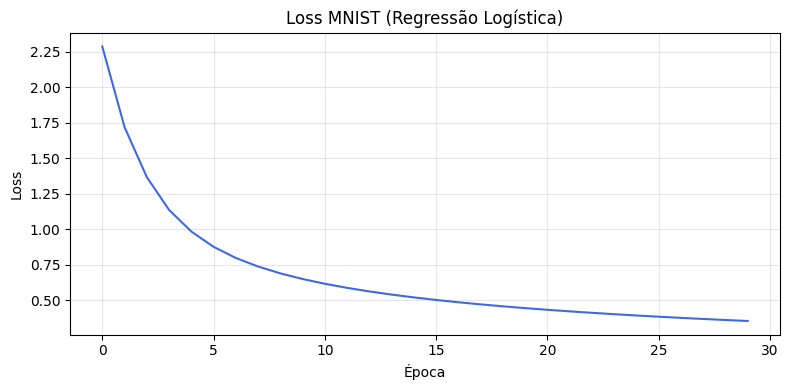

In [21]:
# Exercício 1: Loop de treinamento com impressão por época
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.autograd import Variable

# Reinicializa modelo para demo limpa
torch.manual_seed(42)
dataset_dir_ex = 'MNIST_data/'
train_ds = torchvision.datasets.MNIST(dataset_dir_ex, train=True, download=True,
    transform=torchvision.transforms.ToTensor())
x_tr = train_ds.data.float()[:500] / 255.
y_tr = train_ds.targets[:500]

model_ex = torch.nn.Linear(28*28, 10)
criterion_ex = torch.nn.CrossEntropyLoss()
optimizer_ex = torch.optim.SGD(model_ex.parameters(), lr=0.5)

n_epochs_ex = 30
losses_ex = []
for i in range(n_epochs_ex):
    inputs = Variable(x_tr.view(-1, 28*28))
    outputs = model_ex(inputs)
    loss = criterion_ex(outputs, Variable(y_tr))
    optimizer_ex.zero_grad()
    loss.backward()
    optimizer_ex.step()
    losses_ex.append(loss.item())
    _, preds = torch.max(outputs, 1)
    acc = (preds.data.numpy() == y_tr.numpy()).mean()
    if (i+1) % 10 == 0:
        print(f'Época [{i+1}/{n_epochs_ex}] | Loss: {loss.item():.4f} | Acurácia: {acc*100:.2f}%')

plt.figure(figsize=(8,4))
plt.plot(losses_ex, color='royalblue')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Loss MNIST (Regressão Logística)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### Exercício 2 — Visualização dos Gradientes (Classe 4 - dígito '4')


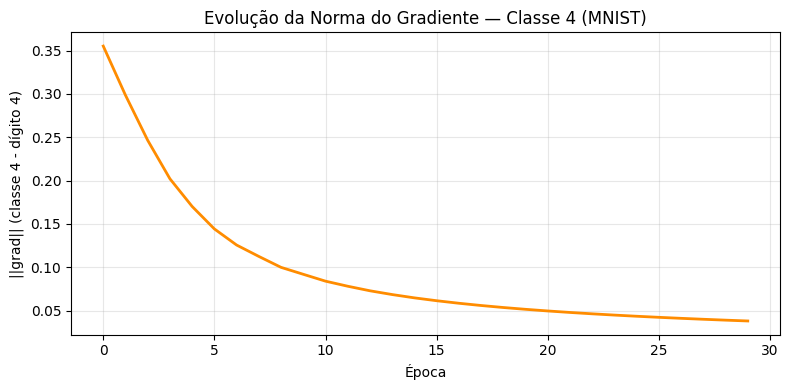

Norma inicial do gradiente (classe 4): 0.3551
Norma final  do gradiente (classe 4): 0.0381


In [22]:
# Exercício 2: Visualizar gradientes do dígito 4 durante treinamento
import numpy as np

torch.manual_seed(42)
model_grad = torch.nn.Linear(28*28, 10)
crit_grad = torch.nn.CrossEntropyLoss()
opt_grad = torch.optim.SGD(model_grad.parameters(), lr=0.5)

grad_norms = []  # norma L2 do gradiente da classe 4

for i in range(30):
    inp = Variable(x_tr.view(-1, 28*28))
    out = model_grad(inp)
    loss = crit_grad(out, Variable(y_tr))
    opt_grad.zero_grad()
    loss.backward()
    grad_class4 = model_grad.weight.grad[4, :]  # gradiente do neurônio da classe 4
    grad_norms.append(grad_class4.norm().item())
    opt_grad.step()

plt.figure(figsize=(8,4))
plt.plot(grad_norms, color='darkorange', linewidth=2)
plt.xlabel('Época'); plt.ylabel('||grad|| (classe 4 - dígito 4)')
plt.title('Evolução da Norma do Gradiente — Classe 4 (MNIST)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f'Norma inicial do gradiente (classe 4): {grad_norms[0]:.4f}')
print(f'Norma final  do gradiente (classe 4): {grad_norms[-1]:.4f}')


### Perguntas — Respostas

1. **Shape da matriz de entrada:** `(N, 784)` — N amostras × 784 pixels (28×28 flatten).
2. **Shape da saída:** `(N, 10)` — N amostras × 10 logits (um por dígito 0–9).
3. **Total de parâmetros:** 784 × 10 pesos + 10 bias = **7.850 parâmetros**.


## Por que os pesos parecem 'fantasmas' dos dígitos?

Cada neurônio de saída aprende um **mapa de importância** dos pixels para sua classe. Em um modelo linear, o peso $w_{c,px}$ indica o quanto o pixel $px$ contribui para o score da classe $c$.

Durante o treinamento, os pixels que **frequentemente aparecem acesos** nos exemplos de uma classe recebem **pesos positivos** (reforçam o score), enquanto pixels de fundo recebem pesos próximos de zero ou negativos.

O resultado é que ao visualizar os pesos reshape(28,28), vemos uma imagem que lembra o dígito correspondente — um 'fantasma' ou 'protótipo' da classe. Por exemplo:
- O neurônio do dígito **'0'** terá pesos altos em pixels que formam um oval.
- O neurônio do **'1'** terá pesos altos em uma faixa vertical estreita.

Isso revela que a regressão logística linear aprende **templates espaciais** — limitação que motivou o uso de CNNs, que aprendem padrões hierárquicos e invariantes à translação.


## Principais Aprendizados

1. O modelo MNIST linear (`nn.Linear(784, 10)`) é uma generalização direta da Regressão Logística para múltiplas classes via **Softmax/CrossEntropy**.
2. Os pesos treinados são interpretáveis: cada linha da matriz `weight[c, :]` é o 'template' do dígito $c$.
3. A acurácia de ~85-90% em 500 amostras mostra as limitações do modelo linear — para MNIST completo e maior acurácia, CNNs são necessárias.
